# 📊 Clinical AI Comparison – ChatGPT vs OpenEvidence (50 Clinical Cases)

### 🧪 Project Overview
This project aims to comparing the clinical reasoning performance of **ChatGPT** and **OpenEvidence** across **50 real-world clinical cases**. Each case has been scored based on a structured **scoring rubric** ranging from 0 to 3 across six key clinical domains.

The goal is to assess whether there are statistically significant differences between the two AI systems in diagnostic accuracy, evidence usage, treatment planning, and more — using non-parametric statistical testing.

---

### 📁 Dataset Description
Each row represents the performance of one AI system (ChatGPT or OpenEvidence) for a specific clinical case. The dataset contains 150 rows (2 systems × 50 cases × some missing data / extra rows).

---

### 🔠 Feature Definitions

| Column Name                | Description                                                                 |
|----------------------------|-----------------------------------------------------------------------------|
| `Case ID`                 | Unique identifier for each clinical scenario (e.g., Case 1, Case 2...)     |
| `Tool`                    | The AI system being evaluated (`ChatGPT` or `OpenEvidence`)                 |
| `Diagnostic Accuracy`     | Score from 0 to 3 based on whether the primary diagnosis was correctly identified |
| `Differential Diagnosis`  | Score from 0 to 3 based on the quality, relevance, and number of differential diagnoses listed |
| `Evidence`                | Score from 0 to 3 based on whether clinical guidelines or references were cited |
| `Treatment Plan`          | Score from 0 to 3 depending on the correctness and completeness of treatment |
| `Labs/Imaging`            | Score from 0 to 3 evaluating interpretation of labs/imaging (may include missing data) |
| `Usability in Practice`   | Score from 0 to 3 measuring how actionable and bedside-ready the plan is |
| `References `          | Categorical indicator of whether references were used (`yes`/`no`)         |
| `Supportive measures`     | Additional care recommendations – may be textual or partially structured    |


---



# Data Preprocessing

In [1]:
from fastai.tabular.all import *
from pandas_summary import DataFrameSummary
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from IPython.display import display
import seaborn as sns

In [2]:
df=pd.read_excel('50 Cases AI Clinical Comparison  (1).xlsx')
df.head()

,Case_ID,Tool,Diagnostic_Accuracy,Evidence,Differential_Diagnosis,Treatment_Plan,Labs_Imaging_interpretation,supportive_measures_remove,References,Usability_in_Practice
0,Case 2,ChatGPT,3,0,3,2,na,Yes,no,3
1,Case 2,OpenEvidence,3,3,Yes,3,Adequate,Yes,Yes,Yes
2,Case 2,HCP,Yes,Yes,Yes,Complete,Adequate,Yes,Yes,Yes
3,Case 1,ChatGPT,3,0,1 (clincally relevant),2,na,Yes,no,2
4,Case 1,OpenEvidence,3,3,1 (clincally relevant),3,na,Yes,Yes,3


In [3]:
# Build a function to use display libraries to show all columns in the dataset
def display_all(df):
    with pd.option_context('display.max_rows',1000):
        with pd.option_context('display.max_columns',1000):
            display(df)

In [4]:
display_all(df.tail(10).transpose())

,140,141,142,143,144,145,146,147,148,149
Case_ID,Case 47,Case 48,Case 48,Case 48,Case 49,Case 49,Case 49,Case 50,Case 50,Case 50
Tool,HCP,ChatGPT,OpenEvidence,HCP,ChatGPT,OpenEvidence,HCP,ChatGPT,OpenEvidence,HCP
Diagnostic_Accuracy,Yes,3,3,Yes,3,3,Yes,3,3,Yes
Evidence,Yes,0,3,Yes,0,3,Yes,0,3,Yes
Differential_Diagnosis,Yes,3,3,Yes,0,3,Yes,3,3,Yes
Treatment_Plan,Complete,2,2,Complete,2,1,Complete,2,2,Complete
Labs_Imaging_interpretation,Adequate,3,3,Adequate,3,3,Adequate,3,3,Adequate
supportive_measures_remove,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes
References,Yes,no,Yes,Yes,no,Yes,Yes,no,Yes,Yes
Usability_in_Practice,Yes,3,2,Yes,3,2,Yes,2,2,Yes


In [5]:
display_all(df.head(10).transpose())

,0,1,2,3,4,5,6,7,8,9
Case_ID,Case 2,Case 2,Case 2,Case 1,Case 1,Case 1,Case 3,Case 3,Case 3,Case 4
Tool,ChatGPT,OpenEvidence,HCP,ChatGPT,OpenEvidence,HCP,ChatGPT,OpenEvidence,HCP,ChatGPT
Diagnostic_Accuracy,3,3,Yes,3,3,Yes,3,3,Yes,3
Evidence,0,3,Yes,0,3,Yes,0,3,Yes,0
Differential_Diagnosis,3,Yes,Yes,1 (clincally relevant),1 (clincally relevant),Yes,3,3,Yes,1
Treatment_Plan,2,3,Complete,2,3,Complete,2,2,Complete,2
Labs_Imaging_interpretation,na,Adequate,Adequate,na,na,Adequate,na,na,Adequate,na
supportive_measures_remove,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes
References,no,Yes,Yes,no,Yes,Yes,no,Yes,Yes,no
Usability_in_Practice,3,Yes,Yes,2,3,Yes,2,2,Yes,3


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 10 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   Case_ID                      150 non-null    object
 1   Tool                         150 non-null    object
 2   Diagnostic_Accuracy          150 non-null    object
 3   Evidence                     150 non-null    object
 4   Differential_Diagnosis       150 non-null    object
 5   Treatment_Plan               150 non-null    object
 6   Labs_Imaging_interpretation  150 non-null    object
 7   supportive_measures_remove   150 non-null    object
 8   References                   150 non-null    object
 9   Usability_in_Practice        150 non-null    object
dtypes: object(10)
memory usage: 11.8+ KB


In [7]:
df=df.astype('category')

In [8]:
# ✅ Remove all rows where Tool is HCP (cleaned string)
df = df[df['Tool'].str.strip() != 'HCP'].copy()
df['Tool'] = df['Tool'].cat.remove_unused_categories()
print(df['Tool'].unique())

['ChatGPT', 'OpenEvidence']
Categories (2, object): ['ChatGPT', 'OpenEvidence']


> 💬 **Note:** The rows labeled with `Tool = HCP` (human responses) were removed from the dataset, as they are not part of the AI model comparison. The remaining dataset includes only `ChatGPT` and `OpenEvidence` responses for analysis.


In [9]:
# Display unique values for each column
for col in df.columns:
    unique_vals = df[col].dropna().unique().tolist()
    print(f"{col}:\n{unique_vals}\n{'-'*50}")

Case_ID:
['Case 2', 'Case 1', 'Case 3', 'Case 4', 'Case 5', 'Case 6', 'Case 7', 'Case 8', 'Case 9', 'Case 10', 'Case 11', 'Case 12', 'Case 13', 'Case 14', 'Case 15', 'Case 16', 'Case 17', 'Case 18', 'Case 19', 'Case 20', 'Case 21', 'Case 22', 'Case 23', 'Case 24', 'Case 25', 'Case 26', 'Case 27', 'Case 28', 'Case 29', 'Case 30', 'Case 31', 'Case 32', 'Case 33', 'Case 34', 'Case 35', 'Case 36', 'Case 37', 'Case 38', 'Case 39', 'Case 40', 'Case 41', 'Case 42', 'Case 43', 'Case 44', 'Case 45', 'Case 46', 'Case 47', 'Case 48', 'Case 49', 'Case 50']
--------------------------------------------------
Tool:
['ChatGPT', 'OpenEvidence']
--------------------------------------------------
Diagnostic_Accuracy:
[3, 1, 2]
--------------------------------------------------
Evidence:
[0, 3, 2]
--------------------------------------------------
Differential_Diagnosis:
[3, 'Yes', '1 (clincally relevant)', 1, 0, 2]
--------------------------------------------------
Treatment_Plan:
[2, 3, 1, 0]
----------

In [10]:
display_all(df.head(10).transpose())

,0,1,3,4,6,7,9,10,12,13
Case_ID,Case 2,Case 2,Case 1,Case 1,Case 3,Case 3,Case 4,Case 4,Case 5,Case 5
Tool,ChatGPT,OpenEvidence,ChatGPT,OpenEvidence,ChatGPT,OpenEvidence,ChatGPT,OpenEvidence,ChatGPT,OpenEvidence
Diagnostic_Accuracy,3,3,3,3,3,3,3,3,3,3
Evidence,0,3,0,3,0,3,0,3,2,3
Differential_Diagnosis,3,Yes,1 (clincally relevant),1 (clincally relevant),3,3,1,3,3,3
Treatment_Plan,2,3,2,3,2,2,2,2,3,2
Labs_Imaging_interpretation,na,Adequate,na,na,na,na,na,na,na,na
supportive_measures_remove,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes
References,no,Yes,no,Yes,no,Yes,no,Yes,Yes,Yes
Usability_in_Practice,3,Yes,2,3,2,2,3,2,3,3


### Encoding the featuers

In [11]:
# ==================================================
# 🟢 Step 4: Encode 'Differential Diagnosis' column
# ==================================================
def encode_differential(val):
    if str(val).strip().lower() == 'yes':
        return 3
    elif val == '1 (clincally relevant)':
        return 1
    try:
        return int(val)
    except:
        return None

df['Differential_Diagnosis'] = df['Differential_Diagnosis'].apply(encode_differential)

# ==================================================
# 🟢  Encode 'Usability in Practice' column
# ==================================================
def encode_usability(val):
    if str(val).strip().lower() == 'yes':
        return 3
    try:
        return int(val)
    except:
        return None

df['Usability_in_Practice'] = df['Usability_in_Practice'].apply(encode_usability)

# ========================================================
# 🟢 Encode 'Labs_Imaging_interpretation' column
# ========================================================
def encode_labs(val):
    val = str(val).strip().lower()
    if val == 'adequate':
        return 2
    elif val == 'yes':
        return 3
    elif val == 'na' or pd.isna(val):
        return 0
    try:
        return int(val)
    except:
        return None

df['Labs_Imaging_interpretation'] = df['Labs_Imaging_interpretation'].apply(encode_labs)
# ========================================================
# 🟢 Encode 'supportive_measures_remove' column
# ========================================================
def encode_supportive(val):
    if str(val).strip().lower() == 'yes':
        return 1
    try:
        return int(val)
    except:
        return None

df['supportive_measures_remove'] = df['supportive_measures_remove'].apply(encode_supportive)
# ========================================================
# 🟢 Encode 'References' column
# ========================================================
def encode_References(val):
    if str(val).strip().lower() == 'yes':
        return 1
    elif val == 'no':
        return 0
    try:
        return int(val)
    except:
        return None

df['References'] = df['References'].apply(encode_References)


In [12]:
# Display unique values for each column
for col in df.columns:
    unique_vals = df[col].dropna().unique().tolist()
    print(f"{col}:\n{unique_vals}\n{'-'*50}")

Case_ID:
['Case 2', 'Case 1', 'Case 3', 'Case 4', 'Case 5', 'Case 6', 'Case 7', 'Case 8', 'Case 9', 'Case 10', 'Case 11', 'Case 12', 'Case 13', 'Case 14', 'Case 15', 'Case 16', 'Case 17', 'Case 18', 'Case 19', 'Case 20', 'Case 21', 'Case 22', 'Case 23', 'Case 24', 'Case 25', 'Case 26', 'Case 27', 'Case 28', 'Case 29', 'Case 30', 'Case 31', 'Case 32', 'Case 33', 'Case 34', 'Case 35', 'Case 36', 'Case 37', 'Case 38', 'Case 39', 'Case 40', 'Case 41', 'Case 42', 'Case 43', 'Case 44', 'Case 45', 'Case 46', 'Case 47', 'Case 48', 'Case 49', 'Case 50']
--------------------------------------------------
Tool:
['ChatGPT', 'OpenEvidence']
--------------------------------------------------
Diagnostic_Accuracy:
[3, 1, 2]
--------------------------------------------------
Evidence:
[0, 3, 2]
--------------------------------------------------
Differential_Diagnosis:
[3, 1, 0, 2]
--------------------------------------------------
Treatment_Plan:
[2, 3, 1, 0]
-------------------------------------------

# Descriptive analysis

In [13]:
# List your encoded columns (update names if you used different ones)
encoded_columns = [
    'Diagnostic_Accuracy',
    'Differential_Diagnosis',
    'Evidence',
    'Treatment_Plan',
    'Labs_Imaging_interpretation',
    'Usability_in_Practice',
    'References',
    'supportive_measures_remove'
    
]
for col in encoded_columns:
    df[col] = pd.to_numeric(df[col], errors='coerce')
# Group by Tool and calculate the mean score for each metric
grouped_means = df.groupby('Tool', observed=True)[encoded_columns].agg(['mean', 'std']).round(2)

# Display the result
print("Step 1: Performance Comparison - ChatGPT vs OpenEvidence")
grouped_means.transpose()


Step 1: Performance Comparison - ChatGPT vs OpenEvidence


Tool                              ChatGPT  OpenEvidence
Diagnostic_Accuracy         mean     2.98          2.90
                            std      0.14          0.42
Differential_Diagnosis      mean     2.08          2.88
                            std      1.26          0.52
Evidence                    mean     0.08          3.00
                            std      0.40          0.00
Treatment_Plan              mean     2.06          2.10
                            std      0.55          0.58
Labs_Imaging_interpretation mean     1.76          1.80
                            std      1.46          1.44
Usability_in_Practice       mean     2.22          1.98
                            std      0.65          0.74
References                  mean     0.04          1.00
                            std      0.20          0.00
supportive_measures_remove  mean     1.00          1.00
                            std      0.00          0.00

In [14]:
# Remove supportive_measures_remove from dataset
df=df.drop(columns=['supportive_measures_remove'],axis=1)
df.head(1)

,Case_ID,Tool,Diagnostic_Accuracy,Evidence,Differential_Diagnosis,Treatment_Plan,Labs_Imaging_interpretation,References,Usability_in_Practice
0,Case 2,ChatGPT,3,0,3,2,0,0,3


> 
The supportive_measures_remove column was removed because it does not contribute to the performance evaluation or statistical testing between the two tools. Keeping only relevant columns helps focus the analysis.
> 

In [15]:
# Step 2: Filter only ChatGPT and OpenEvidence
df = df[df['Tool'].isin(['ChatGPT', 'OpenEvidence'])].copy()

# Step 3: Define general encoding function
def general_encode(val):
    val_str = str(val).strip().lower()
    if val_str == 'yes':
        return 3
    elif val_str == 'adequate':
        return 2
    elif val_str == 'na' or pd.isna(val):
        return 0
    try:
        return int(val)
    except:
        return None

# Step 4: Define columns to encode
columns_to_encode = {
    'Diagnostic_Accuracy': 'Diagnostic_Accuracy',
    'Differential_Diagnosis': 'Differential_Diagnosis',
    'Evidence': 'Evidence',
    'Treatment_Plan': 'Treatment_Plan',
    'Labs_Imaging_interpretation': 'Labs_Encoded',
    'Usability_in_Practice': 'Usability_Encoded',
    'References':'References'
}

# Step 5: Apply encoding
for original, new in columns_to_encode.items():
    df[new] = df[original].apply(general_encode)

# Step 6: Crosstab analysis with clear titles
for col in columns_to_encode.values():
    print("\n" + "="*70)
    print(f"📊 Count Distribution for: {col.replace('_', ' ')}")
    print("="*70)
    print(pd.crosstab(df['Tool'], df[col]))



📊 Count Distribution for: Diagnostic Accuracy
Diagnostic_Accuracy  1  2   3
Tool                         
ChatGPT              0  1  49
OpenEvidence         2  1  47

📊 Count Distribution for: Differential Diagnosis
Differential_Diagnosis   0  1  2   3
Tool                                
ChatGPT                 11  4  5  30
OpenEvidence             1  1  1  47

📊 Count Distribution for: Evidence
Evidence       0  2   3
Tool                   
ChatGPT       48  2   0
OpenEvidence   0  0  50

📊 Count Distribution for: Treatment Plan
Treatment_Plan  0  1   2   3
Tool                        
ChatGPT         0  6  35   9
OpenEvidence    1  3  36  10

📊 Count Distribution for: Labs Encoded
Labs_Encoded   0  2   3
Tool                   
ChatGPT       20  2  28
OpenEvidence  19  3  28

📊 Count Distribution for: Usability Encoded
Usability_Encoded  0  1   2   3
Tool                           
ChatGPT            0  6  27  17
OpenEvidence       2  8  29  11

📊 Count Distribution for: Reference

#  Data Visulization 

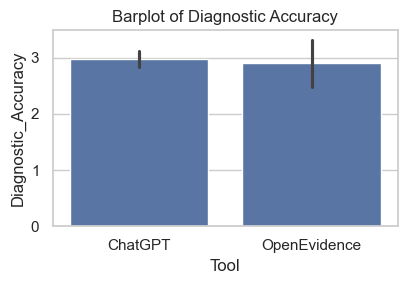

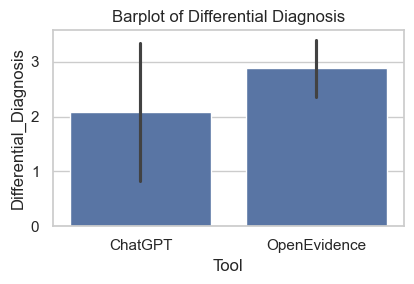

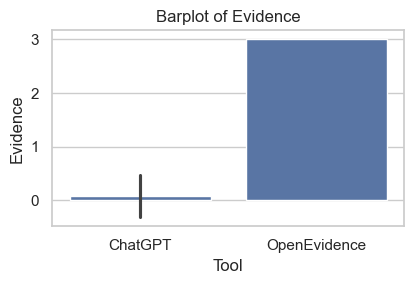

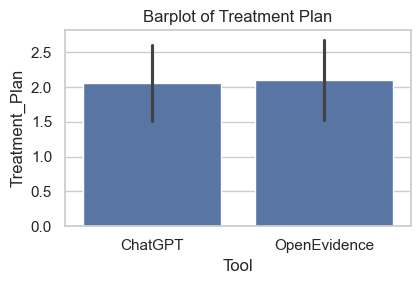

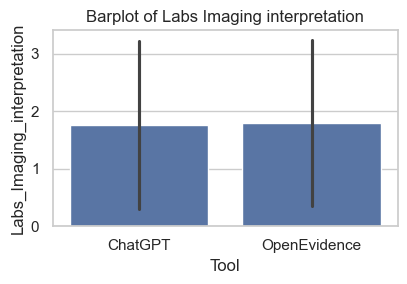

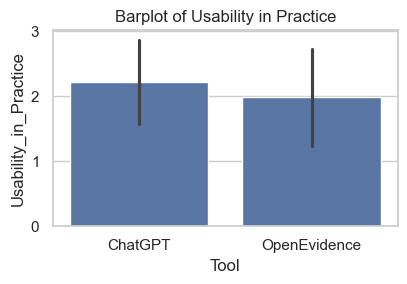

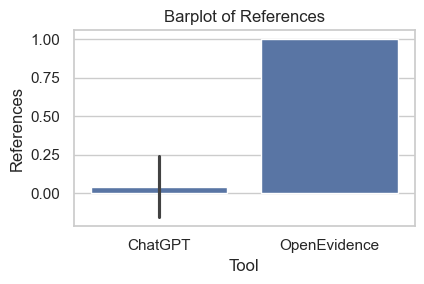

In [16]:

# Set seaborn style
sns.set(style="whitegrid")

# Loop through each column and draw barplot
for col in columns_to_encode:
    plt.figure(figsize=(8, 3))
    
    # Boxplot
    plt.subplot(1, 2, 1)
    sns.barplot(x='Tool', y=col, data=df, errorbar='sd')
    plt.title(f'Barplot of {col.replace("_", " ")}')
    
   

    plt.tight_layout()
    plt.show()

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

# Set seaborn style
sns.set(style="whitegrid")

# Loop through each column and save plot
for col in columns_to_encode:
    plt.figure(figsize=(8, 3))
    
    # Barplot
    sns.barplot(x='Tool', y=col, data=df, errorbar='sd')
    plt.title(f'{col.replace("_", " ")}')

    # Save plot as image (PNG)
    filename = f"/mnt/data/{col}_barplot.png"
    plt.tight_layout()
    plt.savefig(filename, dpi=300)
    plt.close()  # close the plot to avoid displaying it repeatedly



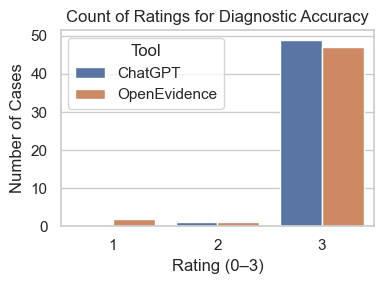

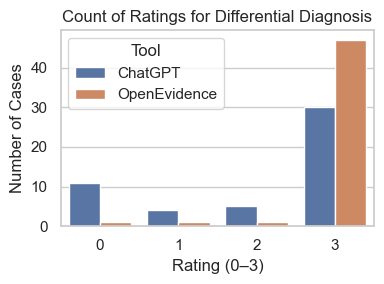

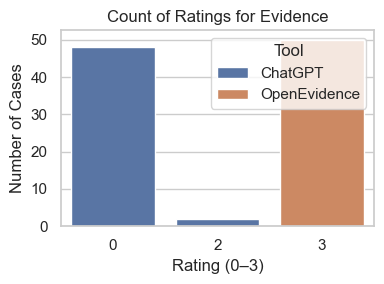

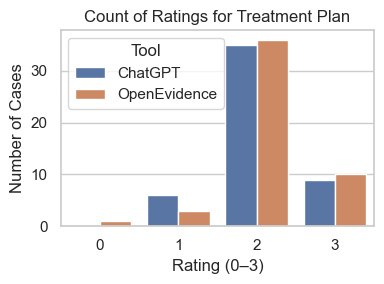

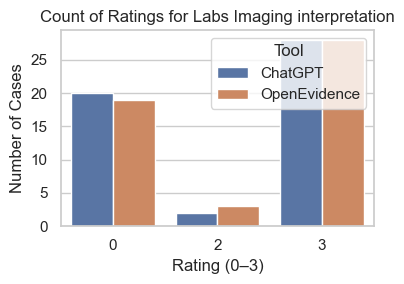

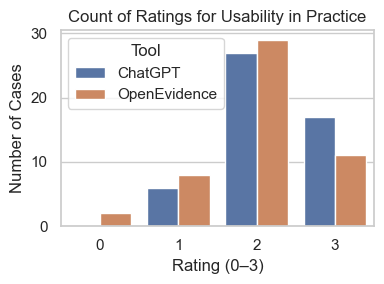

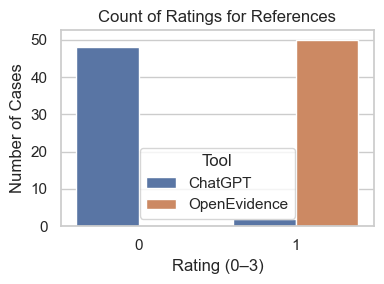

In [18]:
#Count Plot for all measurments
for col in columns_to_encode:
    plt.figure(figsize=(4, 3))
    sns.countplot(data=df, x=col, hue='Tool')
    plt.title(f"Count of Ratings for {col.replace('_', ' ')}")
    plt.xlabel("Rating (0–3)")
    plt.ylabel("Number of Cases")
    plt.legend(title="Tool")
    plt.tight_layout()
    plt.show()

# 📊 Performance Comparison Tests


### 🔹 1-Wilcoxon Signed-Rank Test

In [19]:
df.head()

,Case_ID,Tool,Diagnostic_Accuracy,Evidence,Differential_Diagnosis,Treatment_Plan,Labs_Imaging_interpretation,References,Usability_in_Practice,Labs_Encoded,Usability_Encoded
0,Case 2,ChatGPT,3,0,3,2,0,0,3,0,3
1,Case 2,OpenEvidence,3,3,3,3,2,1,3,2,3
3,Case 1,ChatGPT,3,0,1,2,0,0,2,0,2
4,Case 1,OpenEvidence,3,3,1,3,0,1,3,0,3
6,Case 3,ChatGPT,3,0,3,2,0,0,2,0,2


In [20]:
import pandas as pd
import numpy as np
from scipy.stats import wilcoxon

# Pivot the dataframe by Case ID and Tool
pivot_df = df.pivot(index='Case_ID', columns='Tool')

# Extract each tool's data
chatgpt_data = pivot_df.xs('ChatGPT', axis=1, level=1)
openai_data = pivot_df.xs('OpenEvidence', axis=1, level=1)

# Calculate mean scores for each tool
mean_chatgpt = chatgpt_data.mean()
mean_openai = openai_data.mean()

# Run Wilcoxon test and determine better tool only when result is significant
wilcoxon_results = []

for column in chatgpt_data.columns:
    if column in openai_data.columns:
        x = chatgpt_data[column]
        y = openai_data[column]
        try:
            stat, p = wilcoxon(x, y)
            p_rounded = round(p, 4)
        except:
            p_rounded = np.nan

        # Mean values
        mean_c = mean_chatgpt[column]
        mean_o = mean_openai[column]

        # Determine better tool only if result is significant
        if p_rounded < 0.05:
            if mean_c > mean_o:
                better_tool = "ChatGPT (Significant)"
            elif mean_o > mean_c:
                better_tool = "OpenEvidence (Significant)"
            else:
                better_tool = "Equal"
        else:
            better_tool = "No Significant Difference"

        wilcoxon_results.append({
            'Metric': column,
            'ChatGPT Mean': round(mean_c, 2),
            'OpenEvidence Mean': round(mean_o, 2),
            'P-value': p_rounded,
            'Significant (p < 0.05)': p_rounded < 0.05 if not np.isnan(p_rounded) else False,
            'Better Tool': better_tool
        })

# Create result DataFrame
wilcoxon_df = pd.DataFrame(wilcoxon_results)
wilcoxon_df


,Metric,ChatGPT Mean,OpenEvidence Mean,P-value,Significant (p < 0.05),Better Tool
0,Diagnostic_Accuracy,2.98,2.90,0.1025,False,No Significant Difference
1,Evidence,0.08,3.00,0.0000,True,OpenEvidence (Significant)
2,Differential_Diagnosis,2.08,2.88,0.0001,True,OpenEvidence (Significant)
3,Treatment_Plan,2.06,2.10,0.6972,False,No Significant Difference
4,Labs_Imaging_interpretation,1.76,1.80,0.5809,False,No Significant Difference
5,References,0.04,1.00,0.0000,True,OpenEvidence (Significant)
6,Usability_in_Practice,2.22,1.98,0.0470,True,ChatGPT (Significant)
7,Labs_Encoded,1.76,1.80,0.5809,False,No Significant Difference
8,Usability_Encoded,2.22,1.98,0.0470,True,ChatGPT (Significant)



**This table compares the performance of ChatGPT and OpenEvidence using the Wilcoxon Signed-Rank Test.
A statistically significant difference is detected when the P-value < 0.05, meaning the performance difference is unlikely due to chance.
In such cases, the tool with the higher average score is considered the better-performing one**.

**However, when the difference is not statistically significant, we cannot confidently say one tool is better than the other, regardless of who has the higher average.
That’s why the “Better Tool” column only indicates a winner when the result is statistically significant**.



## 2- Paired T-Test Tool Comparison


In [21]:
from scipy.stats import ttest_rel
import pandas as pd

# Pivot the dataframe to have tool values side by side per case
pivot_df = df.pivot(index='Case_ID', columns='Tool')

# Extract tool-specific values
chatgpt_data = pivot_df.xs('ChatGPT', axis=1, level=1)
openai_data = pivot_df.xs('OpenEvidence', axis=1, level=1)

# Run paired t-test
t_test_results = []

for col in encoded_columns:
    if col in chatgpt_data.columns and col in openai_data.columns:
        x = chatgpt_data[col]
        y = openai_data[col]
        
        t_stat, p_value = ttest_rel(x, y)
        p_rounded = round(p_value, 4)

        mean_c = round(x.mean(), 2)
        mean_o = round(y.mean(), 2)

        # مين الأفضل؟
        if p_rounded < 0.05:
            if mean_c > mean_o:
                better = "ChatGPT (Significant)"
            elif mean_o > mean_c:
                better = "OpenEvidence (Significant)"
            else:
                better = "Equal"
        else:
            better = "No Significant Difference"

        t_test_results.append({
            'Metric': col,
            'ChatGPT Mean': mean_c,
            'OpenEvidence Mean': mean_o,
            'P-value': p_rounded,
            'Significant (p < 0.05)': p_rounded < 0.05,
            'Better Tool': better
        })

#Create result DataFrame
t_test_df = pd.DataFrame(t_test_results)
t_test_df


,Metric,ChatGPT Mean,OpenEvidence Mean,P-value,Significant (p < 0.05),Better Tool
0,Diagnostic_Accuracy,2.98,2.90,0.1030,False,No Significant Difference
1,Differential_Diagnosis,2.08,2.88,0.0000,True,OpenEvidence (Significant)
2,Evidence,0.08,3.00,0.0000,True,OpenEvidence (Significant)
3,Treatment_Plan,2.06,2.10,0.6990,False,No Significant Difference
4,Labs_Imaging_interpretation,1.76,1.80,0.5980,False,No Significant Difference
5,Usability_in_Practice,2.22,1.98,0.0443,True,ChatGPT (Significant)
6,References,0.04,1.00,0.0000,True,OpenEvidence (Significant)



>*Paird t test results show that in metrics where the P-value is less than 0.05, the difference is statistically significant, and the tool with the higher average is considered better*.

>In this case, OpenEvidence significantly outperformed ChatGPT in some key areas such as Evidence Use and Differential Diagnosis, confirming its stronger clinical support 

### Effect size

In [22]:

# Pivot the dataframe
pivot_df = df.pivot(index='Case_ID', columns='Tool')
chatgpt_data = pivot_df.xs('ChatGPT', axis=1, level=1)
openai_data = pivot_df.xs('OpenEvidence', axis=1, level=1)

# Paired T-Test + Cohen's d + Significance column
effect_size_results = []

for col in chatgpt_data.columns:
    if col in openai_data.columns:
        x = chatgpt_data[col]
        y = openai_data[col]
        diff = x - y

        # Paired T-Test
        t_stat, p_value = ttest_rel(x, y)
        p_value = round(p_value, 4)
        significance = "Yes" if p_value < 0.05 else "No"

        # Cohen's d
        mean_diff = np.mean(diff)
        std_diff = np.std(diff, ddof=1)
        cohen_d = round(mean_diff / std_diff, 3) if std_diff != 0 else np.nan

        # Effect size interpretation
        if abs(cohen_d) < 0.2:
            interpretation = 'Negligible'
        elif abs(cohen_d) < 0.5:
            interpretation = 'Small'
        elif abs(cohen_d) < 0.8:
            interpretation = 'Medium'
        else:
            interpretation = 'Large'

        effect_size_results.append({
            'Metric': col,
            'ChatGPT Mean': round(x.mean(), 2),
            'OpenEvidence Mean': round(y.mean(), 2),
            'P-value': p_value,
            'Statistically Significant': significance,
            "Cohen's d": cohen_d,
            'Effect Size Interpretation': interpretation
        })

#Create result DataFrame
effect_size_df = pd.DataFrame(effect_size_results)
effect_size_df


,Metric,ChatGPT Mean,OpenEvidence Mean,P-value,Statistically Significant,Cohen's d,Effect Size Interpretation
0,Diagnostic_Accuracy,2.98,2.90,0.1030,No,0.235,Small
1,Evidence,0.08,3.00,0.0000,Yes,-7.376,Large
2,Differential_Diagnosis,2.08,2.88,0.0000,Yes,-0.669,Medium
3,Treatment_Plan,2.06,2.10,0.6990,No,-0.055,Negligible
4,Labs_Imaging_interpretation,1.76,1.80,0.5980,No,-0.075,Negligible
5,References,0.04,1.00,0.0000,Yes,-4.850,Large
6,Usability_in_Practice,2.22,1.98,0.0443,Yes,0.292,Small
7,Labs_Encoded,1.76,1.80,0.5980,No,-0.075,Negligible
8,Usability_Encoded,2.22,1.98,0.0443,Yes,0.292,Small


    
    Cohen’s d was calculated to measure the effect size — the magnitude of difference between ChatGPT and OpenEvidence scores.
    Unlike P-values which only indicate whether a difference exists, effect size quantifies how substantial that difference is.
    Values of 0.2, 0.5, and 0.8 are interpreted as small, medium, and large effects respectively.
    This provides deeper insight into practical significance, especially when P-values alone may be sensitive to sample size.



## Summary Table

In [23]:

# Summary results

paired_results = t_test_df.to_dict('records')  # Convert DataFrame rows to dicts

# Initialize the summary table list
summary_table = []

# Loop through each row of the three test result lists
for w_row, t_row, e_row in zip(wilcoxon_results, paired_results, effect_size_results):
    summary_table.append({
        'Metric': w_row['Metric'],
        'ChatGPT Mean': w_row['ChatGPT Mean'],
        'OpenEvidence Mean': w_row['OpenEvidence Mean'],
        'Wilcoxon P-value': w_row['P-value'],
        'Wilcoxon Better Tool': w_row['Better Tool'],
        'T-Test P-value': t_row['P-value'],
        'Statistically Significant': e_row['Statistically Significant'],
        'T-Test Better Tool': t_row['Better Tool'],
        "Cohen's d": e_row["Cohen's d"],
        'Effect Size Interpretation': e_row['Effect Size Interpretation']
    })

# Convert the list of dictionaries to a summary DataFrame
summary_df = pd.DataFrame(summary_table)

# Show the summary
summary_df



,Metric,ChatGPT Mean,OpenEvidence Mean,Wilcoxon P-value,Wilcoxon Better Tool,T-Test P-value,Statistically Significant,T-Test Better Tool,Cohen's d,Effect Size Interpretation
0,Diagnostic_Accuracy,2.98,2.90,0.1025,No Significant Difference,0.1030,No,No Significant Difference,0.235,Small
1,Evidence,0.08,3.00,0.0000,OpenEvidence (Significant),0.0000,Yes,OpenEvidence (Significant),-7.376,Large
2,Differential_Diagnosis,2.08,2.88,0.0001,OpenEvidence (Significant),0.0000,Yes,OpenEvidence (Significant),-0.669,Medium
3,Treatment_Plan,2.06,2.10,0.6972,No Significant Difference,0.6990,No,No Significant Difference,-0.055,Negligible
4,Labs_Imaging_interpretation,1.76,1.80,0.5809,No Significant Difference,0.5980,No,No Significant Difference,-0.075,Negligible
5,References,0.04,1.00,0.0000,OpenEvidence (Significant),0.0443,Yes,ChatGPT (Significant),-4.850,Large
6,Usability_in_Practice,2.22,1.98,0.0470,ChatGPT (Significant),0.0000,Yes,OpenEvidence (Significant),0.292,Small
